In [ ]:
!pip install -q datasets huggingface_hub

from datasets import load_dataset
from huggingface_hub import login

# 👉 Log in to HF (needed only if you plan to push later)
login()


In [ ]:
# Load the CLEANED training dataset (with target_verse_clean + previous_verses_clean)
ds_train = load_dataset("Shaer-AI/ashaar-training-split", split="train")

print(ds_train)
print(ds_train.column_names)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_clean'],
    num_rows: 1102121
})
['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_clean']


In [ ]:
def norm_optional_text(x):
    """
    Normalize optional string fields:
    - None / 'null' / '' -> ""
    - otherwise -> stripped string
    """
    if x is None:
        return ""
    s = str(x).strip()
    if s == "" or s.lower() in {"null", "none", "nan"}:
        return ""
    return s

def build_previous_verses_block(prev_verses):
    """
    prev_verses: list of full verses (from previous_verses_clean)
    Returns the text block to insert under:
    'الأبيات السابقة في القصيدة:'
    """
    if not prev_verses:
        return "لا توجد أبيات سابقة، فهذا هو البيت الأول في القصيدة."
    lines = []
    for i, verse in enumerate(prev_verses):
        lines.append(f"{i+1}) {verse}")
    return "\n".join(lines)


In [ ]:
def build_instruction(example):
    """
    Build the Arabic instruction string for one row.
    Uses:
    - poem_title
    - poem_meter
    - poem_theme
    - poet_era
    - poet_name
    - poem_description
    - num_verses
    - sequence_number
    - previous_verses_clean
    """
    meter       = norm_optional_text(example.get("poem_meter"))
    theme       = norm_optional_text(example.get("poem_theme"))
    poet_era    = norm_optional_text(example.get("poet_era"))
    poet_name   = norm_optional_text(example.get("poet_name"))
    description = norm_optional_text(example.get("poem_description"))

    num_verses  = example.get("num_verses")
    seq_num     = example.get("sequence_number")
    prev_verses = example.get("previous_verses_clean", [])

    lines = []

    # مقدمة
    lines.append("المطلوب منك في هذه المهمة أن تولّد بيتًا شعريًا واحدًا فقط، وفق المواصفات التالية:\n")

    # حقول فقط إذا موجودة
    if meter:
        lines.append(f"- البحر: {meter}")
    if theme:
        lines.append(f"- النوع: {theme}")
    if description:
        lines.append(f"- الوصف العام لموضوع القصيدة: {description}")
    if poet_era:
        lines.append(f"- العصر: {poet_era}")
    if poet_name:
        lines.append(f"- الشاعر: {poet_name}")
    if num_verses is not None:
        lines.append(f"- عدد أبيات القصيدة الكلي: {num_verses}")
    if seq_num is not None:
        lines.append(f"- ترتيب البيت المطلوب داخل القصيدة: {seq_num}")

    # الأبيات السابقة
    lines.append("\nالأبيات السابقة في القصيدة:")
    prev_block = build_previous_verses_block(prev_verses)
    lines.append(prev_block)

    # إرشادات مختصرة
    lines.append("\nإرشادات مهمة:")
    lines.append("- أخرج بيتًا واحدًا مكوّنًا من صدر وعجز في سطر واحد.")
    lines.append("- التزم بالبحر الشعري، وبجوّ ومعنى القصيدة كما في الوصف والأبيات السابقة (إن وُجدت).")
    lines.append("- لا تكرّر أي بيت سابق ولا تضف شروحًا أو عناوين أو علامات خاصة؛ الناتج هو البيت فقط.")

    instruction_text = "\n".join(lines)
    return instruction_text


In [ ]:
# ثابت لكل الأمثلة
SYSTEM_MESSAGE = {
    "role": "system",
    "content": (
        "أنت شاعر عربي متمكن من مختلف البحور والأغراض الشعرية، "
        "وقادر على محاكاة أساليب الشعراء عبر العصور مع الحفاظ على سلامة اللغة، "
        "والوزن، والقافية."
    ),
}

def build_messages(example):
    """
    Build the `messages` list for one example:
    [
      {"role": "system", ...},
      {"role": "user", "content": <Instructions>},
      {"role": "assistant", "content": <target_verse_clean>}
    ]
    """
    user_instruction = build_instruction(example)
    target = example.get("target_verse_clean", "")

    messages = [
        SYSTEM_MESSAGE,
        {"role": "user", "content": user_instruction},
        {"role": "assistant", "content": target},
    ]
    return messages


In [ ]:
for i in range(3):
    ex = ds_train[i]
    msgs = build_messages(ex)

    print("=" * 80)
    print(f"🧾 Example {i}")
    print("\nMessages structure:\n")
    print(msgs)
    print("\nSystem content:\n", msgs[0]["content"])
    print("\nUser (Instructions):\n", msgs[1]["content"])
    print("\nAssistant (target_verse_clean):\n", msgs[2]["content"])
    print("\n")


🧾 Example 0

Messages structure:

[{'role': 'system', 'content': 'أنت شاعر عربي متمكن من مختلف البحور والأغراض الشعرية، وقادر على محاكاة أساليب الشعراء عبر العصور مع الحفاظ على سلامة اللغة، والوزن، والقافية.'}, {'role': 'user', 'content': 'المطلوب منك في هذه المهمة أن تولّد بيتًا شعريًا واحدًا فقط، وفق المواصفات التالية:\n\n- البحر: الخفيف\n- النوع: قصيدة رومنسيه\n- الوصف العام لموضوع القصيدة: قصيدة "ما على القلب بعدكم من جناح" تتحدث عن الشوق والحزن بعد الفراق، معبرة عن مشاعر الحنين والألم. الشاعر يصف كيف أن قلبه يعاني من الفراق، وكيف أن الشوق يزداد بمرور الوقت. كما يشير إلى أن الفراق لا يعني نهاية الحب، بل يظل الحب قوياً رغم البعد.\n- العصر: العصر المملوكي\n- الشاعر: لسان الدين بن الخطيب\n- عدد أبيات القصيدة الكلي: 96\n- ترتيب البيت المطلوب داخل القصيدة: 1\n\nالأبيات السابقة في القصيدة:\nلا توجد أبيات سابقة، فهذا هو البيت الأول في القصيدة.\n\nإرشادات مهمة:\n- أخرج بيتًا واحدًا مكوّنًا من صدر وعجز في سطر واحد.\n- التزم بالبحر الشعري، وبجوّ ومعنى القصيدة كما في الوصف والأبيات السابقة (إ

In [ ]:
def add_instruction_and_messages(example):
    instr = build_instruction(example)
    msgs = [
        SYSTEM_MESSAGE,
        {"role": "user", "content": instr},
        {"role": "assistant", "content": example.get("target_verse_clean", "")},
    ]
    return {
        "Instructions": instr,
        "messages": msgs,
    }

ds_train_instr = ds_train.map(add_instruction_and_messages)

print(ds_train_instr)
print(ds_train_instr.column_names)

# Quick sanity check
row0 = ds_train_instr[0]
print("\n🔎 Row 0 messages:\n", row0["messages"])
print("\n🔎 Row 0 Instructions:\n", row0["Instructions"])
print("\n🔎 Row 0 target_verse_clean:\n", row0["target_verse_clean"])


Map:   0%|          | 0/1102121 [00:00<?, ? examples/s]

Dataset({
    features: ['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_clean', 'Instructions', 'messages'],
    num_rows: 1102121
})
['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_clean', 'Instructions', 'messages']

🔎 Row 0 messages:
 [{'content': 'أنت شاعر عربي متمكن من مختلف البحور والأغراض الشعرية، وقادر على محاكاة أساليب الشعراء عبر العصور مع الحفاظ على سلامة اللغة، والوزن، والقافية.', 'role': 'system'}, {'content': 'المطلوب منك في هذه المهمة أن تولّد بيتًا شعريًا واحدًا فقط، وفق المواصفات التالية:\n\n- ال

In [ ]:
repo_id = "Shaer-AI/ashaar-training-instructions-2"

ds_train_instr.push_to_hub(repo_id)
print(f"✅ Pushed training dataset with instructions to: {repo_id}")


Uploading the dataset shards:   0%|          | 0/29 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/39 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   7%|6         | 3.16MB / 46.1MB            

...

Creating parquet from Arrow format:   0%|          | 0/39 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  12%|#1        | 5.50MB / 47.7MB            

✅ Pushed training dataset with instructions to: Shaer-AI/ashaar-training-instructions-2


In [ ]:
# ─────────────────────────────────────────────
# Build validation instructions + messages
# ─────────────────────────────────────────────

from datasets import load_dataset

print("🔹 Loading CLEANED validation split ...")
ds_val = load_dataset("Shaer-AI/ashaar-validation-split", split="train")
print("Validation original columns:", ds_val.column_names)

# Add Instructions + messages using the SAME helper as training
ds_val_instr = ds_val.map(add_instruction_and_messages)

print("Validation with instructions columns:", ds_val_instr.column_names)

# Quick sanity check
row0_val = ds_val_instr[0]
print("\n🔎 Validation row 0 — messages:\n", row0_val["messages"])
print("\n🔎 Validation row 0 — Instructions:\n", row0_val["Instructions"])
print("\n🔎 Validation row 0 — target_verse_clean:\n", row0_val["target_verse_clean"])

# Push to HF
val_repo_id = "Shaer-AI/ashaar-validation-instructions-2"
print(f"\n⬆️ Pushing validation dataset to: {val_repo_id} ...")
ds_val_instr.push_to_hub(val_repo_id)

print(f"\n✅ DONE: validation dataset with instructions pushed to {val_repo_id}")


🔹 Loading CLEANED validation split ...


README.md:   0%|          | 0.00/988 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/25.6M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/139085 [00:00<?, ? examples/s]

...

Creating parquet from Arrow format:   0%|          | 0/35 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  14%|#3        | 5.87MB / 42.1MB            


✅ DONE: validation dataset with instructions pushed to Shaer-AI/ashaar-validation-instructions-2


In [ ]:
# ─────────────────────────────────────────────
# Build testing instructions + messages
# ─────────────────────────────────────────────

print("🔹 Loading CLEANED testing split ...")
ds_test = load_dataset("Shaer-AI/ashaar-testing-split", split="train")
print("Testing original columns:", ds_test.column_names)

# Add Instructions + messages using the SAME helper as training
ds_test_instr = ds_test.map(add_instruction_and_messages)

print("Testing with instructions columns:", ds_test_instr.column_names)

# Quick sanity check
row0_test = ds_test_instr[0]
print("\n🔎 Testing row 0 — messages:\n", row0_test["messages"])
print("\n🔎 Testing row 0 — Instructions:\n", row0_test["Instructions"])
print("\n🔎 Testing row 0 — target_verse_clean:\n", row0_test["target_verse_clean"])

# Push to HF
test_repo_id = "Shaer-AI/ashaar-testing-instructions-2"
print(f"\n⬆️ Pushing testing dataset to: {test_repo_id} ...")
ds_test_instr.push_to_hub(test_repo_id)

print(f"\n✅ DONE: testing dataset with instructions pushed to {test_repo_id}")


🔹 Loading CLEANED testing split ...


README.md:   0%|          | 0.00/988 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/25.2M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/25.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/136475 [00:00<?, ? examples/s]

...

Creating parquet from Arrow format:   0%|          | 0/35 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   6%|5         | 2.33MB / 40.9MB            


✅ DONE: testing dataset with instructions pushed to Shaer-AI/ashaar-testing-instructions-2


In [ ]:
!pip install -q datasets huggingface_hub pandas matplotlib

from datasets import load_dataset
from huggingface_hub import login
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
# CLEANED datasets with num_verses + poem_id
ds_train = load_dataset("Shaer-AI/ashaar-training-split", split="train")
ds_val   = load_dataset("Shaer-AI/ashaar-validation-split", split="train")

print(ds_train)
print(ds_val)
print("Train columns:", ds_train.column_names)
print("Val columns:", ds_val.column_names)


Dataset({
    features: ['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_clean'],
    num_rows: 1102121
})
Dataset({
    features: ['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_clean'],
    num_rows: 139085
})
Train columns: ['poem_title', 'poem_meter', 'poem_theme', 'poem_url', 'poet_name', 'poet_description', 'poet_url', 'poet_era', 'poet_location', 'poem_language_type', 'num_verses', 'poem_id', 'poem_description', 'target_verse', 'previous_verses', 'sequence_number', 'target_verse_clean', 'previous_verses_cle

In [ ]:
def get_poem_level_df(ds):
    """
    Convert HF dataset -> pandas DataFrame with one row per unique poem_id.
    We keep the first occurrence of each poem_id.
    """
    df = ds.to_pandas()
    df_poems = df.drop_duplicates(subset="poem_id", keep="first")
    return df_poems

def describe_num_verses(df_poems, split_name="train"):
    """
    Show:
      - basic stats
      - full frequency of num_verses
      - binned ranges counts
    """
    print(f"\n{'='*60}")
    print(f"📊 Split: {split_name}")
    print(f"Number of unique poems: {len(df_poems)}")

    # Basic statistics
    print("\nBasic statistics for num_verses:")
    print(df_poems["num_verses"].describe())

    # Exact frequency table
    print("\nExact frequency table (num_verses -> count of poems):")
    freq = df_poems["num_verses"].value_counts().sort_index()
    print(freq)

    # Define bins / ranges (you can tweak these)
    bins = [0, 5, 10, 20, 40, 80, 200, 10000]
    labels = [
        "1–5",
        "6–10",
        "11–20",
        "21–40",
        "41–80",
        "81–200",
        ">200",
    ]
    df_poems["num_verses_range"] = pd.cut(df_poems["num_verses"], bins=bins, labels=labels)

    print("\nCounts per num_verses range (poems per range):")
    print(df_poems["num_verses_range"].value_counts().sort_index())

    # Optional: visualize histogram
    plt.figure()
    df_poems["num_verses"].hist(bins=50)
    plt.title(f"Distribution of num_verses ({split_name}) — poem-level")
    plt.xlabel("num_verses")
    plt.ylabel("Number of poems")
    plt.show()



📊 Split: train
Number of unique poems: 94643

Basic statistics for num_verses:
count    94643.000000
mean        11.645034
std         15.199983
min          1.000000
25%          2.000000
50%          5.000000
75%         15.000000
max        110.000000
Name: num_verses, dtype: float64

Exact frequency table (num_verses -> count of poems):
num_verses
1       5261
2      23732
3       9616
4       7980
5       5106
       ...  
106        5
107        7
108        6
109        4
110        5
Name: count, Length: 110, dtype: int64

Counts per num_verses range (poems per range):
num_verses_range
1–5       51695
6–10      13516
11–20     11739
21–40     11429
41–80      5842
81–200      422
>200          0
Name: count, dtype: int64


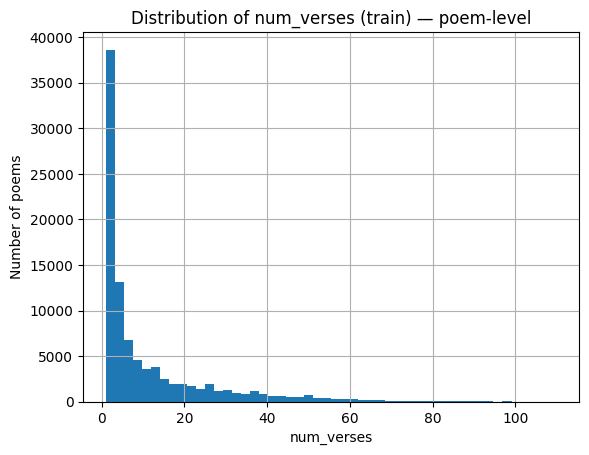


📊 Split: validation
Number of unique poems: 11831

Basic statistics for num_verses:
count    11831.000000
mean        11.755980
std         15.429064
min          1.000000
25%          2.000000
50%          5.000000
75%         15.000000
max        110.000000
Name: num_verses, dtype: float64

Exact frequency table (num_verses -> count of poems):
num_verses
1       649
2      2975
3      1244
4      1011
5       632
       ... 
106       1
107       2
108       1
109       2
110       1
Name: count, Length: 104, dtype: int64

Counts per num_verses range (poems per range):
num_verses_range
1–5       6511
6–10      1631
11–20     1446
21–40     1419
41–80      763
81–200      61
>200         0
Name: count, dtype: int64


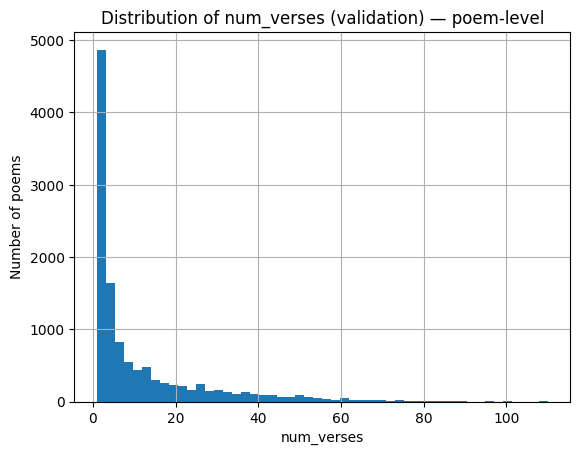

In [ ]:
df_train_poems = get_poem_level_df(ds_train)
df_val_poems   = get_poem_level_df(ds_val)

describe_num_verses(df_train_poems, split_name="train")
describe_num_verses(df_val_poems, split_name="validation")


In [ ]:
!pip install -q datasets huggingface_hub

from datasets import load_dataset

# ─────────────────────────────────────────────
# Helper: keep only poems with num_verses ≤ 20
# ─────────────────────────────────────────────

def keep_short_poems(example):
    nv = example.get("num_verses", None)
    # In case there are weird Nones, treat them as keep
    if nv is None:
        return True
    return nv <= 20

# ─────────────────────────────────────────────
# 1) TRAINING: load, filter, push
# ─────────────────────────────────────────────

train_src = "Shaer-AI/ashaar-training-instructions-2"
train_tgt = "Shaer-AI/ashaar-training-instructions-short"

print(f"🔹 Loading {train_src} ...")
ds_train = load_dataset(train_src, split="train")
print("Before filtering (train):", len(ds_train))

ds_train_short = ds_train.filter(keep_short_poems)
print("After filtering (train, num_verses ≤ 20):", len(ds_train_short))

# Optional: sanity check
print("Sample num_verses values (train):", sorted(set(ds_train_short[:100]["num_verses"])))

print(f"\n⬆️ Pushing filtered training dataset to {train_tgt} ...")
ds_train_short.push_to_hub(train_tgt)
print(f"✅ Done: {train_tgt}")

# ─────────────────────────────────────────────
# 2) VALIDATION: load, filter, push
# ─────────────────────────────────────────────

val_src = "Shaer-AI/ashaar-validation-instructions-2"
val_tgt = "Shaer-AI/ashaar-validation-instructions-short"

print(f"\n🔹 Loading {val_src} ...")
ds_val = load_dataset(val_src, split="train")
print("Before filtering (validation):", len(ds_val))

ds_val_short = ds_val.filter(keep_short_poems)
print("After filtering (validation, num_verses ≤ 20):", len(ds_val_short))

# Optional: sanity check
print("Sample num_verses values (validation):", sorted(set(ds_val_short[:100]["num_verses"])))

print(f"\n⬆️ Pushing filtered validation dataset to {val_tgt} ...")
ds_val_short.push_to_hub(val_tgt)
print(f"✅ Done: {val_tgt}")


🔹 Loading Shaer-AI/ashaar-training-instructions-2 ...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

data/train-00000-of-00029.parquet:   0%|          | 0.00/46.1M [00:00<?, ?B/s]

...

Creating parquet from Arrow format:   0%|          | 0/26 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  18%|#7        | 4.15MB / 23.6MB            

✅ Done: Shaer-AI/ashaar-validation-instructions-short
